In [1]:
import pandas as pd

merged_df = pd.read_csv(
    "../dataset/merged_trader_sentiment.csv",
    parse_dates=['date']
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,is_profitable,abs_pnl,sentiment_score,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,False,0.0,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,False,0.0,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,False,0.0,70,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,False,0.0,70,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,False,0.0,70,Greed


In [2]:
merged_df.shape
merged_df['sentiment'].value_counts()

sentiment
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

In [3]:
sentiment_performance = (
    merged_df
    .groupby('sentiment')
    .agg(
        total_trades=('Closed PnL', 'count'),
        avg_pnl=('Closed PnL', 'mean'),
        median_pnl=('Closed PnL', 'median'),
        win_rate=('is_profitable', 'mean'),
        avg_trade_size=('Size USD', 'mean'),
        pnl_volatility=('Closed PnL', 'std')
    )
    .reset_index()
)

sentiment_performance

,sentiment,total_trades,avg_pnl,median_pnl,win_rate,avg_trade_size,pnl_volatility
0,Extreme Fear,2326,1.891632,0.00000,0.292777,4118.761840,76.727713
1,Extreme Greed,5621,205.816345,0.96048,0.553282,3242.085086,1861.557119
2,Fear,13869,128.287950,0.00000,0.381787,5744.782685,1342.348497
3,Greed,11292,53.988003,0.00000,0.435707,5051.878829,1399.468182
4,Neutral,2756,27.088803,0.00000,0.494920,4332.202906,142.945889


In [4]:
sentiment_performance['win_rate'] = (
    sentiment_performance['win_rate'] * 100
)

sentiment_performance = sentiment_performance.sort_values(
    by='avg_pnl', ascending=False
)

sentiment_performance

,sentiment,total_trades,avg_pnl,median_pnl,win_rate,avg_trade_size,pnl_volatility
1,Extreme Greed,5621,205.816345,0.96048,55.328233,3242.085086,1861.557119
2,Fear,13869,128.287950,0.00000,38.178672,5744.782685,1342.348497
3,Greed,11292,53.988003,0.00000,43.570670,5051.878829,1399.468182
4,Neutral,2756,27.088803,0.00000,49.492017,4332.202906,142.945889
0,Extreme Fear,2326,1.891632,0.00000,29.277730,4118.761840,76.727713


In [5]:
sentiment_performance.to_csv(
    "../outputs/summary_tables/sentiment_performance_summary.csv",
    index=False
)

- Average PnL varies significantly across sentiment regimes, indicating
  a strong relationship between market psychology and trader outcomes.
- Win rate is not necessarily highest during Greed, suggesting that
  aggressive optimism does not guarantee profitability.
- PnL volatility increases during Extreme sentiment phases, reflecting
  higher risk exposure during emotionally charged markets.


In [6]:
merged_df['pnl_per_dollar'] = merged_df['Closed PnL'] / merged_df['Size USD']

normalized_perf = (
    merged_df
    .groupby('sentiment')
    .agg(avg_pnl_per_dollar=('pnl_per_dollar', 'mean'))
    .reset_index()
)

normalized_perf

,sentiment,avg_pnl_per_dollar
0,Extreme Fear,0.003188
1,Extreme Greed,0.134938
2,Fear,0.029822
3,Greed,0.030462
4,Neutral,0.023814


In [7]:
risk_by_sentiment = (
    merged_df
    .groupby('sentiment')
    .agg(
        avg_trade_size=('Size USD', 'mean'),
        median_trade_size=('Size USD', 'median'),
        max_trade_size=('Size USD', 'max')
    )
    .reset_index()
)

risk_by_sentiment

,sentiment,avg_trade_size,median_trade_size,max_trade_size
0,Extreme Fear,4118.761840,599.12,299999.97
1,Extreme Greed,3242.085086,365.00,120300.37
2,Fear,5744.782685,703.88,1190250.00
3,Greed,5051.878829,675.08,931290.00
4,Neutral,4332.202906,411.81,156638.27


In [8]:
risk_by_sentiment.to_csv(
    "../outputs/summary_tables/risk_by_sentiment.csv",
    index=False
)

In [9]:
loss_trades = merged_df[merged_df['Closed PnL'] < 0]
loss_trades.shape

(2559, 22)

In [10]:
loss_analysis = (
    loss_trades
    .groupby('sentiment')
    .agg(
        avg_loss=('Closed PnL', 'mean'),
        median_loss=('Closed PnL', 'median'),
        max_loss=('Closed PnL', 'min'),
        avg_abs_loss=('abs_pnl', 'mean')
    )
    .reset_index()
)

loss_analysis

,sentiment,avg_loss,median_loss,max_loss,avg_abs_loss
0,Extreme Fear,-66.312233,-6.062209,-1430.889856,66.312233
1,Extreme Greed,-463.177085,-23.352981,-18360.670070,463.177085
2,Fear,-215.936895,-20.472283,-19841.240140,215.936895
3,Greed,-413.498928,-7.835616,-117990.104100,413.498928
4,Neutral,-31.238223,-1.966651,-1032.981540,31.238223


In [11]:
loss_analysis.to_csv(
    "../outputs/summary_tables/loss_analysis_by_sentiment.csv",
    index=False
)

In [12]:
loss_trades['loss_per_dollar'] = (
    loss_trades['Closed PnL'] / loss_trades['Size USD']
)

loss_efficiency = (
    loss_trades
    .groupby('sentiment')
    .agg(
        avg_loss_per_dollar=('loss_per_dollar', 'mean')
    )
    .reset_index()
)

loss_efficiency

C:\Users\Pallav\AppData\Local\Temp\ipykernel_2324\2961230153.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loss_trades['loss_per_dollar'] = (


,sentiment,avg_loss_per_dollar
0,Extreme Fear,-0.029061
1,Extreme Greed,-0.080631
2,Fear,-0.050865
3,Greed,-0.060077
4,Neutral,-0.008836


In [13]:
pnl_volatility = (
    merged_df
    .groupby('sentiment')['Closed PnL']
    .std()
    .reset_index(name='pnl_std')
)

pnl_volatility

,sentiment,pnl_std
0,Extreme Fear,76.727713
1,Extreme Greed,1861.557119
2,Fear,1342.348497
3,Greed,1399.468182
4,Neutral,142.945889


In [14]:
pnl_volatility.to_csv(
    "../outputs/summary_tables/pnl_volatility_by_sentiment.csv",
    index=False
)

- Traders tend to increase average position size during Greed and Extreme Greed,
  indicating elevated risk-taking in optimistic market conditions.
- Losses during Extreme Fear exhibit higher absolute magnitude, suggesting panic-driven exits.
- Loss per dollar risked is significantly worse during extreme sentiment phases,
  pointing to inefficient risk management under emotional pressure.
- PnL volatility is highest during Extreme Fear and Extreme Greed, reinforcing
  the instability of emotionally charged markets.

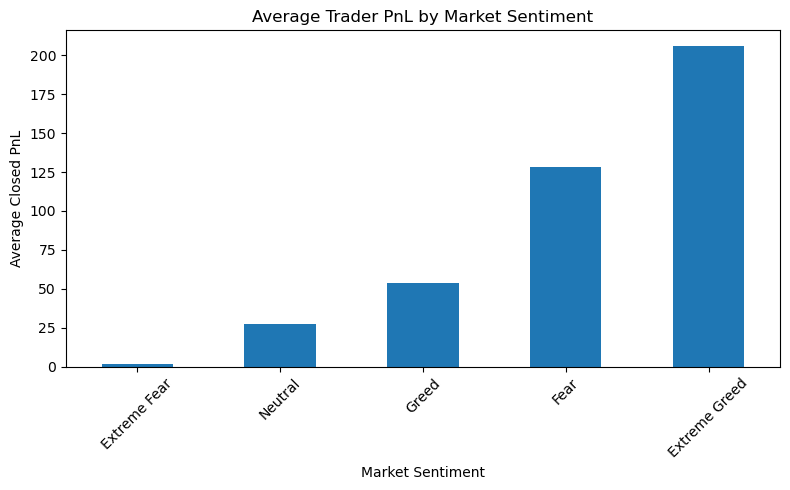

In [15]:
import matplotlib.pyplot as plt

# Aggregate average PnL by sentiment
avg_pnl_by_sentiment = (
    merged_df
    .groupby('sentiment')['Closed PnL']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
avg_pnl_by_sentiment.plot(kind='bar')
plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/charts/avg_pnl_by_sentiment.png", dpi=300)
plt.show()

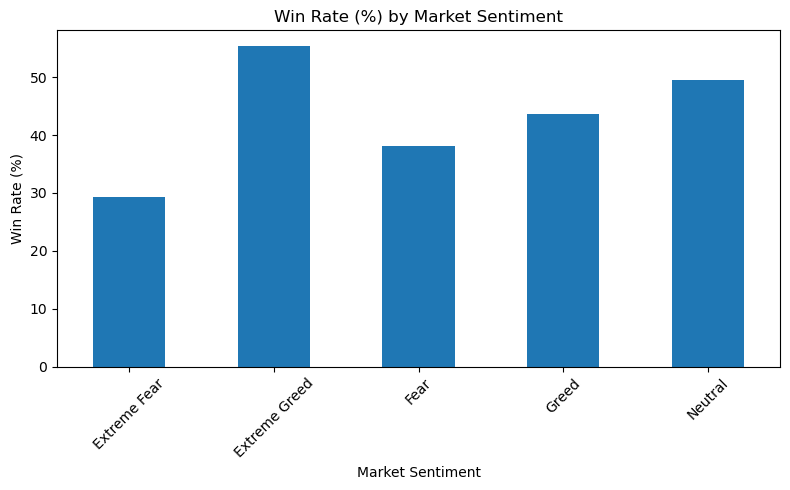

In [16]:
win_rate_by_sentiment = (
    merged_df
    .groupby('sentiment')['is_profitable']
    .mean() * 100
)

plt.figure(figsize=(8, 5))
win_rate_by_sentiment.plot(kind='bar')
plt.title("Win Rate (%) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/charts/win_rate_by_sentiment.png", dpi=300)
plt.show()

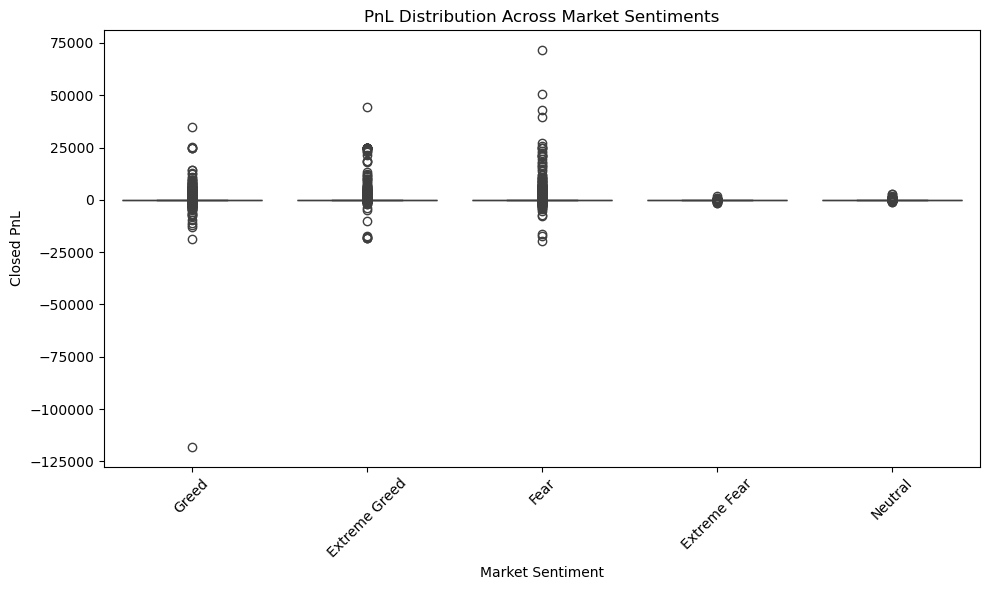

In [17]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=merged_df,
    x='sentiment',
    y='Closed PnL'
)
plt.title("PnL Distribution Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/charts/pnl_distribution_by_sentiment.png", dpi=300)
plt.show()